# Imputation Methods

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('src'), '..')))

from src.constants import IRIS_DATASET_ID
from src.datasets import load_openml_dataset
from src.missingness import *
from src.imputation import *
from src.visualize import *
from src.metrics import *

## Iris Dataset
Load the Iris dataset as an example

In [2]:
IRIS_DATASET = load_openml_dataset(IRIS_DATASET_ID)
iris_values = IRIS_DATASET.drop(columns=["class"]).values
print(IRIS_DATASET)

     sepallength  sepalwidth  petallength  petalwidth           class
0            5.1         3.5          1.4         0.2     Iris-setosa
1            4.9         3.0          1.4         0.2     Iris-setosa
2            4.7         3.2          1.3         0.2     Iris-setosa
3            4.6         3.1          1.5         0.2     Iris-setosa
4            5.0         3.6          1.4         0.2     Iris-setosa
..           ...         ...          ...         ...             ...
145          6.7         3.0          5.2         2.3  Iris-virginica
146          6.3         2.5          5.0         1.9  Iris-virginica
147          6.5         3.0          5.2         2.0  Iris-virginica
148          6.2         3.4          5.4         2.3  Iris-virginica
149          5.9         3.0          5.1         1.8  Iris-virginica

[150 rows x 5 columns]


## Introduce Missingness
Applying Multivariate MCAR as an Example Missingness Introduction

In [3]:
corrupted_iris = multivariat_mcar(IRIS_DATASET, "class", 10, seed=42)
mask = np.isnan(corrupted_iris)

# Imputation Methods
This section applies and compares various imputation methods to repair the corrupted datasets.

In [4]:
restored_iris_mean = impute_simple(corrupted_iris, "mean")
restored_iris_median = impute_simple(corrupted_iris, "median")
restored_iris_mode = impute_simple(corrupted_iris, "most_frequent")
restored_iris_constant = impute_simple(corrupted_iris, "constant")
restored_iris_knn = impute_knn(corrupted_iris)
restored_iris_iterative = impute_iterative(corrupted_iris)
restored_iris_mice = impute_mice(corrupted_iris)

# MSE Comparison
Calculate the Mean Squared Error (MSE) for the imputation methods to visualize their effectiveness.

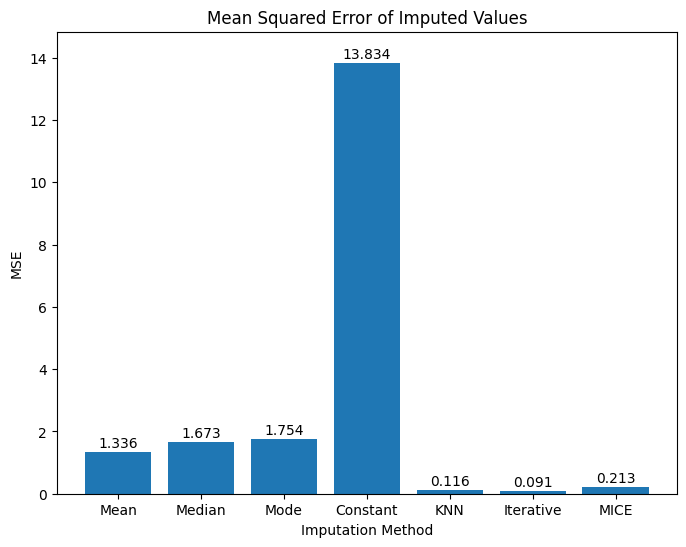

In [5]:
mse_mean = mse(iris_values, restored_iris_mean, mask)
mse_median = mse(iris_values, restored_iris_median, mask)
mse_mode = mse(iris_values, restored_iris_mode, mask)
mse_constant = mse(iris_values, restored_iris_constant, mask)
mse_knn = mse(iris_values, restored_iris_knn, mask)
mse_iterative = mse(iris_values, restored_iris_iterative, mask)
mse_mice = mse(iris_values, restored_iris_mice, mask)

methods = ['Mean', 'Median', 'Mode', 'Constant', 'KNN', 'Iterative', 'MICE']
mse_values = [mse_mean, mse_median, mse_mode, mse_constant, mse_knn, mse_iterative, mse_mice]

plot_bar_chart(methods, mse_values, 'Imputation Method', 'MSE', 'Mean Squared Error of Imputed Values')